# Hourly Pressure And Parallel Task Analysis

This notebook compares the backend-specific monday_ds proposal artifacts produced by:

- `greedy`
- `cp_sat`
- `milp`

It focuses on the same scheduler-burden metrics as before, but now reflects three important modeling updates:

- hour-of-day extraction is normalized in UTC before building pressure and effective-start profiles
- the monday_ds model now carries an explicit `fork -> plum` sequencing rule
- proposal markdown now distinguishes modeled effective finishes used by the solver from representative finishes used only for visualization

Important interpretation rules:

- `observed` peak values are exact historical overlap maxima and are the only numbers in this notebook that should be compared directly to Airflow limits such as `parallelism = 24`.
- `current_shifted_exact` and backend `proposed_shifted_exact` peak values are rigid-shift counterfactuals built from exact historical task intervals. They answer: what would hourly exact overlap look like if each scoped DAG kept the same realized task trace and was only shifted by the schedule delta?
- `current_estimated` and backend `proposed` peak values are synthetic replay metrics built from historically aligned successful run-day combinations. They remain useful as secondary diagnostics, but they are not direct infrastructure sizing targets.
- for sequencing questions, use proposed effective starts plus modeled effective finishes from the refreshed markdown/csv artifacts, not representative finish columns.

Expected files in `artifacts/`:

- `monday_ds_hourly_pressure_parallel_greedy.csv`
- `monday_ds_hourly_pressure_parallel_cp_sat.csv`
- `monday_ds_hourly_pressure_parallel_milp.csv`
- `monday_ds_schedule_proposal_greedy.csv`
- `monday_ds_schedule_proposal_cp_sat.csv`
- `monday_ds_schedule_proposal_milp.csv`
- `monday_ds_observed_global_limits.csv`
- `monday_ds_observed_per_dag_limits.csv`

If you want a notebook kernel locally, install the optional dependency group first:

```bash
uv sync --extra dev --extra notebook
```


In [111]:
from pathlib import Path
import math
import pandas as pd

try:
    from IPython.display import SVG, Markdown, display
except ImportError:
    SVG = None
    Markdown = None
    display = None


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise FileNotFoundError('Could not locate the hypergraph_scheduler repository root.')


scope_id = 'monday_ds'
solvers = ['greedy', 'cp_sat', 'milp']
solver_labels = {'greedy': 'Greedy', 'cp_sat': 'CP-SAT', 'milp': 'MILP'}
solver_colors = {'greedy': '#d97706', 'cp_sat': '#2563eb', 'milp': '#7c3aed'}
repo_root = find_repo_root()
artifacts_dir = repo_root / 'artifacts'
observed_global_limits = pd.read_csv(artifacts_dir / f'{scope_id}_observed_global_limits.csv')
observed_per_dag_limits = pd.read_csv(artifacts_dir / f'{scope_id}_observed_per_dag_limits.csv')
hourly_frames = {}
proposal_frames = {}
missing_files = []
for solver in solvers:
    hourly_path = artifacts_dir / f'{scope_id}_hourly_pressure_parallel_{solver}.csv'
    proposal_path = artifacts_dir / f'{scope_id}_schedule_proposal_{solver}.csv'
    if not hourly_path.exists():
        missing_files.append(str(hourly_path))
        continue
    if not proposal_path.exists():
        missing_files.append(str(proposal_path))
        continue
    hourly_frames[solver] = pd.read_csv(hourly_path)
    proposal_frames[solver] = pd.read_csv(proposal_path)

if missing_files:
    raise FileNotFoundError('Missing comparison artifacts:\n' + '\n'.join(missing_files))

base = hourly_frames['greedy'].copy()
base['hour_index'] = range(len(base))
comparison = base[[
    'hour',
    'hour_index',
    'global_avg_concurrency_current',
    'global_peak_parallel_tasks_current',
    'global_peak_parallel_tasks_current_shifted_exact',
    'global_peak_parallel_tasks_current_estimated',
    'ds_avg_concurrency_current',
    'ds_peak_parallel_tasks_current',
    'ds_peak_parallel_tasks_current_shifted_exact',
    'ds_peak_parallel_tasks_current_estimated',
]].copy()

for solver in solvers:
    frame = hourly_frames[solver]
    comparison[f'global_avg_concurrency_{solver}'] = frame['global_avg_concurrency_proposed']
    comparison[f'global_peak_parallel_tasks_{solver}'] = frame['global_peak_parallel_tasks_proposed']
    comparison[f'global_peak_parallel_tasks_shifted_exact_{solver}'] = frame['global_peak_parallel_tasks_proposed_shifted_exact']
    comparison[f'ds_avg_concurrency_{solver}'] = frame['ds_avg_concurrency_proposed']
    comparison[f'ds_peak_parallel_tasks_{solver}'] = frame['ds_peak_parallel_tasks_proposed']
    comparison[f'ds_peak_parallel_tasks_shifted_exact_{solver}'] = frame['ds_peak_parallel_tasks_proposed_shifted_exact']

comparison.head()

,hour,hour_index,global_avg_concurrency_current,global_peak_parallel_tasks_current,global_peak_parallel_tasks_current_shifted_exact,global_peak_parallel_tasks_current_estimated,ds_avg_concurrency_current,ds_peak_parallel_tasks_current,ds_peak_parallel_tasks_current_shifted_exact,ds_peak_parallel_tasks_current_estimated,...,global_peak_parallel_tasks_shifted_exact_cp_sat,ds_avg_concurrency_cp_sat,ds_peak_parallel_tasks_cp_sat,ds_peak_parallel_tasks_shifted_exact_cp_sat,global_avg_concurrency_milp,global_peak_parallel_tasks_milp,global_peak_parallel_tasks_shifted_exact_milp,ds_avg_concurrency_milp,ds_peak_parallel_tasks_milp,ds_peak_parallel_tasks_shifted_exact_milp
0,00:00,0,0.75,12,14,12,0.00,0,1,0,...,14,0.00,0,1,0.75,12,14,0.00,0,1
1,01:00,1,0.50,13,14,13,0.00,0,0,0,...,15,0.00,0,1,0.50,13,15,0.00,0,1
2,02:00,2,2.00,12,15,12,0.00,2,6,0,...,14,0.00,0,0,2.00,12,14,0.00,0,0
3,03:00,3,5.38,16,22,16,0.00,0,0,0,...,22,0.00,0,0,5.38,16,22,0.00,0,0
4,04:00,4,6.25,22,24,46,0.14,0,0,24,...,24,0.99,24,0,7.11,46,24,0.99,24,0


## Metric Definitions

- **Global pressure / average concurrency**: hourly average of the all-DAG running-task profile. This is an estimated workload indicator, not the hard acceptance metric used by `concurrency_first`.
- **Global peak parallel tasks**: current observed values are exact historical maxima; current/proposed `shifted_exact` values are rigid-shift exact counterfactuals built from real task intervals; current/proposed replay values are secondary synthetic diagnostics.
- **DS pressure / average concurrency**: hourly average of the DS-scoped contribution to global running tasks.
- **DS peak parallel tasks**: current observed values are exact historical maxima; current/proposed `shifted_exact` values are rigid-shift exact counterfactuals for scoped DAGs; replay values remain secondary diagnostics.
- **Observed limits**: exact historical interval-overlap peaks from task-instance and dag-run data; use these to compare against Airflow caps directly.

The backend comparison should be read in three passes:

1. Compare proposed **average concurrency** lines across `greedy`, `cp_sat`, and `milp` to understand the estimated sustained orchestrator burden.
2. Compare proposed **shifted exact peak** lines against exact observed history and `parallelism` to answer the rigid-shift counterfactual.
3. Use **replay peak** lines only as a secondary stress-test diagnostic.

For peak comparisons against Airflow limits, prefer **exact observed** versus backend-specific **proposed shifted exact**.
For replay diagnostics, the fair baseline is **estimated current** versus backend-specific **estimated proposed**, because both are built from the same replay model.

When multiple backend curves appear to be missing, check the solver outcome table first: under `concurrency_first`, identical no-change outputs are drawn on top of each other, so the last rendered line can hide the others visually.
A no-change proposal can still show small average-concurrency differences, because the average-concurrency series is reconstructed from the scoped load model and historical pressure estimates rather than recomputed from the exact task intervals used by `shifted_exact`.



In [ ]:
global_peak_row = observed_global_limits.loc[observed_global_limits['subject'] == 'all_dags'].iloc[0]
scoped_peak_row = observed_global_limits.loc[observed_global_limits['subject'] == scope_id].iloc[0]
breaches = observed_per_dag_limits[~observed_per_dag_limits['within_max_active_runs_per_dag'].astype(str).isin(['True', 'true', '1'])]

current_global_observed_max = int(comparison['global_peak_parallel_tasks_current'].max())
current_global_shifted_exact_max = int(comparison['global_peak_parallel_tasks_current_shifted_exact'].max())
current_global_replay_max = int(comparison['global_peak_parallel_tasks_current_estimated'].max())
current_ds_observed_max = int(comparison['ds_peak_parallel_tasks_current'].max())
current_ds_shifted_exact_max = int(comparison['ds_peak_parallel_tasks_current_shifted_exact'].max())
current_ds_replay_max = int(comparison['ds_peak_parallel_tasks_current_estimated'].max())

peak_reference = pd.DataFrame([
    {'scope': 'Global', 'exact_observed_peak': current_global_observed_max, 'exact_shifted_current_peak': current_global_shifted_exact_max, 'synthetic_replay_current_peak': current_global_replay_max, 'interpretation': 'Use exact observed and shifted exact for Airflow sizing comparisons; use replay current only for replay-to-replay diagnostics.'},
    {'scope': 'Scoped DS', 'exact_observed_peak': current_ds_observed_max, 'exact_shifted_current_peak': current_ds_shifted_exact_max, 'synthetic_replay_current_peak': current_ds_replay_max, 'interpretation': 'Use exact observed and shifted exact for scoped counterfactuals; use replay current only to compare replayed proposals.'},
])

backend_summary = pd.DataFrame([
    {
        'solver': solver_labels[solver],
        'max_global_shifted_exact_peak_proposed': int(comparison[f'global_peak_parallel_tasks_shifted_exact_{solver}'].max()),
        'max_ds_shifted_exact_peak_proposed': int(comparison[f'ds_peak_parallel_tasks_shifted_exact_{solver}'].max()),
        'global_avg_task_hours_proposed': round(float(comparison[f'global_avg_concurrency_{solver}'].sum()), 2),
        'ds_avg_task_hours_proposed': round(float(comparison[f'ds_avg_concurrency_{solver}'].sum()), 2),
        'wait_saved_minutes': int(proposal_frames[solver]['wait_saved_minutes'].sum()),
        'changed_dags': int((proposal_frames[solver]['shift_minutes'] != 0).sum()),
    }
    for solver in solvers
])

def _peak_hour_and_value(column: str) -> tuple[str, int]:
    peak_value = int(comparison[column].max())
    peak_hour = comparison.loc[comparison[column] == peak_value, 'hour'].iloc[0]
    return peak_hour, peak_value

exact_shift_peak_hours = pd.DataFrame([
    {
        'solver': solver_labels[solver],
        'global_shifted_exact_peak': global_peak_value,
        'global_shifted_exact_peak_hour_utc': global_peak_hour,
        'global_delta_vs_observed': global_peak_value - current_global_observed_max,
        'ds_shifted_exact_peak': ds_peak_value,
        'ds_shifted_exact_peak_hour_utc': ds_peak_hour,
        'ds_delta_vs_observed': ds_peak_value - current_ds_observed_max,
    }
    for solver in solvers
    for (global_peak_hour, global_peak_value) in [_peak_hour_and_value(f'global_peak_parallel_tasks_shifted_exact_{solver}')]
    for (ds_peak_hour, ds_peak_value) in [_peak_hour_and_value(f'ds_peak_parallel_tasks_shifted_exact_{solver}')]
])

sequencing_summary = pd.DataFrame([
    {
        'solver': solver_labels[solver],
        'fork_ready_utc': proposal_frames[solver].loc[proposal_frames[solver]['dag_id'] == 'fork', 'estimated_upstream_ready_utc'].iloc[0],
        'fork_effective_start_utc': proposal_frames[solver].loc[proposal_frames[solver]['dag_id'] == 'fork', 'proposed_effective_start_utc'].iloc[0],
        'plum_ready_utc': proposal_frames[solver].loc[proposal_frames[solver]['dag_id'] == 'plum', 'estimated_upstream_ready_utc'].iloc[0],
        'plum_effective_start_utc': proposal_frames[solver].loc[proposal_frames[solver]['dag_id'] == 'plum', 'proposed_effective_start_utc'].iloc[0],
        'note': 'Use refreshed markdown for modeled effective-finish checks; representative finish columns are descriptive only.',
    }
    for solver in solvers
])

best_global_solver = backend_summary.sort_values(['max_global_shifted_exact_peak_proposed', 'global_avg_task_hours_proposed', 'wait_saved_minutes'], ascending=[True, True, False]).iloc[0]
best_ds_solver = backend_summary.sort_values(['max_ds_shifted_exact_peak_proposed', 'ds_avg_task_hours_proposed', 'wait_saved_minutes'], ascending=[True, True, False]).iloc[0]

summary_lines = [
    '### Observed Peak Summary',
    '',
    f"- Global observed running-task peak: **{int(global_peak_row['observed_peak'])}** tasks at {global_peak_row['peak_time']}",
    f"- Global exact shifted-current peak: **{current_global_shifted_exact_max}** tasks",
    f"- Scoped observed running-task peak: **{int(scoped_peak_row['observed_peak'])}** tasks at {scoped_peak_row['peak_time']}",
    f"- Scoped exact shifted-current peak: **{current_ds_shifted_exact_max}** tasks",
    f"- Historical DAGs exceeding max_active_runs_per_dag: **{len(breaches)}**",
    '',
    'Interpretation note: exact observed and shifted exact peaks are the main lines for Airflow-limit discussion; replay peaks are only secondary diagnostics.',
    '',
    '### Backend Summary',
    '',
    f"- Best global exact-shift result in the current artifacts: **{best_global_solver['solver']}** with a proposed global shifted-exact peak of **{int(best_global_solver['max_global_shifted_exact_peak_proposed'])}**.",
    f"- Best scoped exact-shift result in the current artifacts: **{best_ds_solver['solver']}** with a proposed scoped shifted-exact peak of **{int(best_ds_solver['max_ds_shifted_exact_peak_proposed'])}**.",
    '- The monday_ds model now carries an explicit `fork -> plum` sequencing rule.',
    '- Proposal CSV effective starts are safe to compare directly; representative finish columns in markdown are descriptive unless you use the refreshed modeled-finish columns.',
]

if display is not None and Markdown is not None:
    display(Markdown('\n'.join(summary_lines)))
    display(Markdown('### Exact Observed Vs Exact Shifted Vs Replay Reference'))
    display(peak_reference)
    display(Markdown('### Exact-Shift Peak Hour And Delta Vs Observed'))
    display(exact_shift_peak_hours)
    display(Markdown('### Backend Summary Table'))
    display(backend_summary)
    display(Markdown('### Fork / Plum Sequencing Check'))
    display(sequencing_summary)
    display(Markdown('### Global And Scoped Limits'))
    display(observed_global_limits)
    display(Markdown('### Per-DAG Task And Run Limits'))
    display(observed_per_dag_limits)
else:
    print('\n'.join(line.replace('**', '') for line in summary_lines))
    print(backend_summary.to_string(index=False))
    print(sequencing_summary.to_string(index=False))


In [113]:
def _format_value(value: float) -> str:
    return f'{value:.2f}'.rstrip('0').rstrip('.')


def build_svg_line_chart(
    frame: pd.DataFrame,
    title: str,
    y_label: str,
    series: list[tuple[str, str, str]],
    horizontal_lines: list[tuple[float, str, str]] | None = None,
) -> str:
    width = 1080
    height = 470
    margin_left = 82
    margin_right = 28
    margin_top = 58
    margin_bottom = 110
    plot_width = width - margin_left - margin_right
    plot_height = height - margin_top - margin_bottom

    x_values = frame['hour_index'].tolist()
    y_max = max(frame[column].max() for _, column, _ in series)
    if horizontal_lines:
        y_max = max(y_max, max(value for value, _, _ in horizontal_lines))
    y_max = max(1.0, y_max * 1.15)

    def x_pos(hour_index: int) -> float:
        if len(x_values) == 1:
            return margin_left + plot_width / 2
        return margin_left + (hour_index / (len(x_values) - 1)) * plot_width

    def y_pos(value: float) -> float:
        return margin_top + plot_height - (value / y_max) * plot_height

    svg_parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<style>',
        'text { font-family: ui-sans-serif, -apple-system, BlinkMacSystemFont, Segoe UI, sans-serif; fill: #17202a; }',
        '.title { font-size: 22px; font-weight: 700; }',
        '.axis { font-size: 11px; fill: #4b5563; }',
        '.legend { font-size: 12px; }',
        '.grid { stroke: #d8dee9; stroke-width: 1; }',
        '.axis-line { stroke: #6b7280; stroke-width: 1.2; }',
        '</style>',
        '<rect x="0" y="0" width="100%" height="100%" fill="#fcfcf7" />',
        '<rect x="24" y="24" width="1032" height="422" rx="18" fill="#fffdf6" stroke="#eadfcb" />',
        f'<text class="title" x="{margin_left}" y="36">{title}</text>',
    ]

    for step in range(6):
        value = y_max * step / 5
        y = y_pos(value)
        svg_parts.append(f'<line class="grid" x1="{margin_left}" y1="{y:.2f}" x2="{width - margin_right}" y2="{y:.2f}" />')
        svg_parts.append(f'<text class="axis" x="{margin_left - 12}" y="{y + 4:.2f}" text-anchor="end">{_format_value(value)}</text>')

    if horizontal_lines:
        for value, color, label in horizontal_lines:
            y = y_pos(value)
            svg_parts.append(f'<line x1="{margin_left}" y1="{y:.2f}" x2="{width - margin_right}" y2="{y:.2f}" stroke="{color}" stroke-width="2" stroke-dasharray="8 6" />')
            svg_parts.append(f'<text class="axis" x="{width - margin_right - 4}" y="{y - 6:.2f}" text-anchor="end" fill="{color}">{label}</text>')

    svg_parts.append(f'<line class="axis-line" x1="{margin_left}" y1="{margin_top + plot_height}" x2="{width - margin_right}" y2="{margin_top + plot_height}" />')
    svg_parts.append(f'<line class="axis-line" x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{margin_top + plot_height}" />')

    for hour_index, hour_label in zip(frame['hour_index'], frame['hour']):
        if hour_index % 2 != 0:
            continue
        x = x_pos(hour_index)
        svg_parts.append(f'<line class="grid" x1="{x:.2f}" y1="{margin_top}" x2="{x:.2f}" y2="{margin_top + plot_height}" stroke-dasharray="2 6" />')
        svg_parts.append(f'<text class="axis" x="{x:.2f}" y="{height - 62}" text-anchor="middle">{hour_label}</text>')

    svg_parts.append(f'<text class="axis" x="{width / 2:.2f}" y="{height - 38}" text-anchor="middle">UTC hour</text>')
    svg_parts.append(f'<text class="axis" x="24" y="{margin_top + plot_height / 2:.2f}" transform="rotate(-90 24 {margin_top + plot_height / 2:.2f})" text-anchor="middle">{y_label}</text>')

    legend_items_per_row = 2
    legend_row_height = 20
    legend_start_y = height - 28 - legend_row_height * math.ceil(len(series) / legend_items_per_row)
    for index, (label, column, color) in enumerate(series):
        points = ' '.join(f'{x_pos(int(hour_index)):.2f},{y_pos(float(value)):.2f}' for hour_index, value in zip(frame['hour_index'], frame[column]))
        svg_parts.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="3" stroke-linecap="round" stroke-linejoin="round" />')
        last_x = x_pos(int(frame['hour_index'].iloc[-1]))
        last_y = y_pos(float(frame[column].iloc[-1]))
        svg_parts.append(f'<circle cx="{last_x:.2f}" cy="{last_y:.2f}" r="4" fill="{color}" />')
        row = index // legend_items_per_row
        col = index % legend_items_per_row
        legend_x = margin_left + col * 430
        legend_y = legend_start_y + row * legend_row_height
        svg_parts.append(f'<rect x="{legend_x}" y="{legend_y}" width="14" height="14" rx="4" fill="{color}" />')
        svg_parts.append(f'<text class="legend" x="{legend_x + 22}" y="{legend_y + 12}">{label}</text>')

    svg_parts.append('</svg>')
    return ''.join(svg_parts)


def show_svg(svg_text: str) -> None:
    if SVG is not None and display is not None:
        display(SVG(svg_text))
    else:
        print(svg_text)

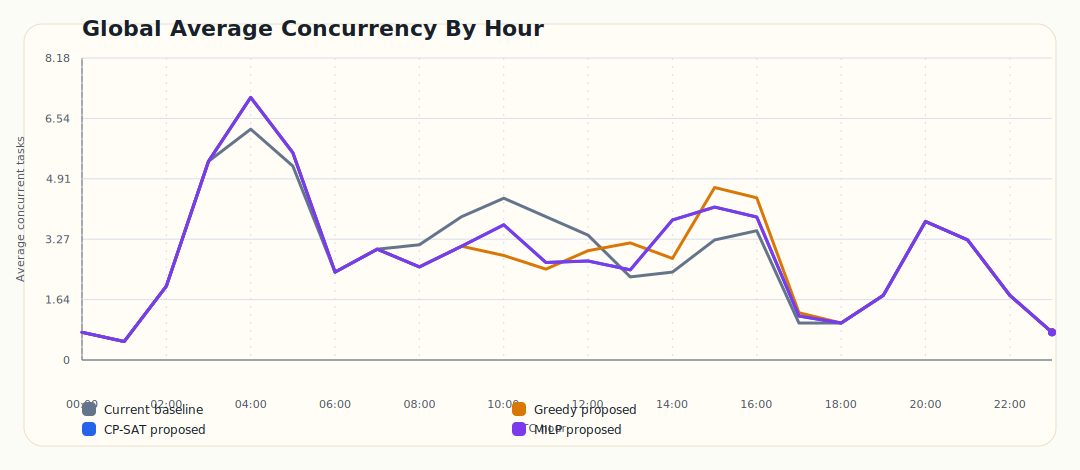

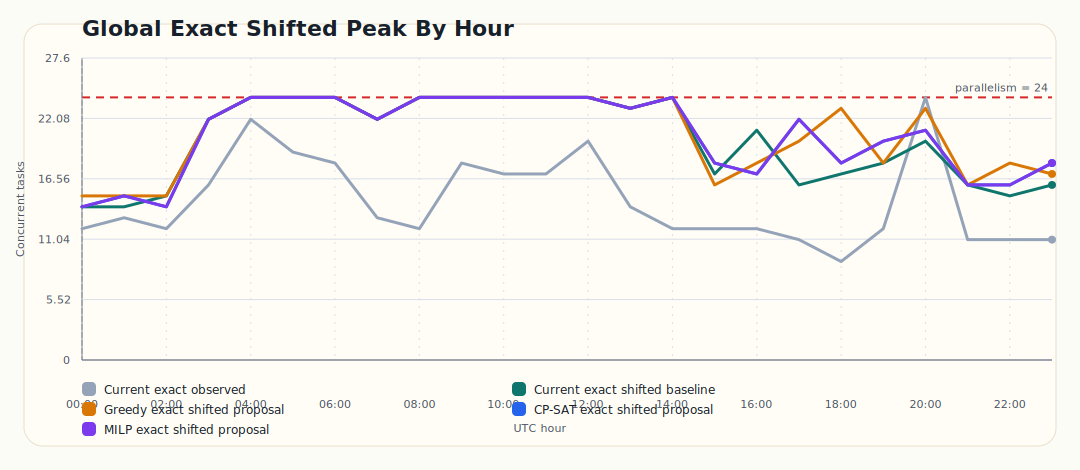

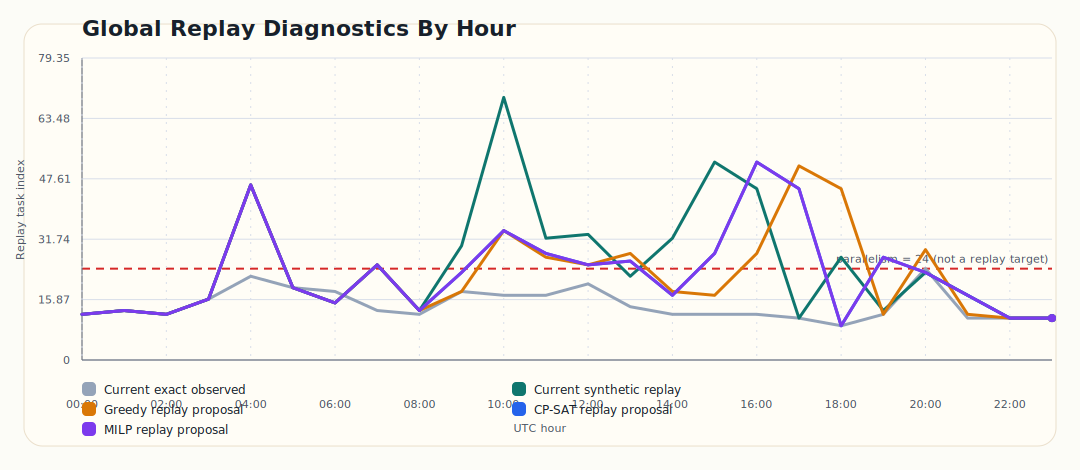

In [114]:
show_svg(
    build_svg_line_chart(
        comparison,
        title='Global Average Concurrency By Hour',
        y_label='Average concurrent tasks',
        series=[
            ('Current baseline', 'global_avg_concurrency_current', '#64748b'),
            ('Greedy proposed', 'global_avg_concurrency_greedy', solver_colors['greedy']),
            ('CP-SAT proposed', 'global_avg_concurrency_cp_sat', solver_colors['cp_sat']),
            ('MILP proposed', 'global_avg_concurrency_milp', solver_colors['milp']),
        ],
    )
)

show_svg(
    build_svg_line_chart(
        comparison,
        title='Global Exact Shifted Peak By Hour',
        y_label='Concurrent tasks',
        series=[
            ('Current exact observed', 'global_peak_parallel_tasks_current', '#94a3b8'),
            ('Current exact shifted baseline', 'global_peak_parallel_tasks_current_shifted_exact', '#0f766e'),
            ('Greedy exact shifted proposal', 'global_peak_parallel_tasks_shifted_exact_greedy', solver_colors['greedy']),
            ('CP-SAT exact shifted proposal', 'global_peak_parallel_tasks_shifted_exact_cp_sat', solver_colors['cp_sat']),
            ('MILP exact shifted proposal', 'global_peak_parallel_tasks_shifted_exact_milp', solver_colors['milp']),
        ],
        horizontal_lines=[(24, '#d62828', 'parallelism = 24')],
    )
)

show_svg(
    build_svg_line_chart(
        comparison,
        title='Global Replay Diagnostics By Hour',
        y_label='Replay task index',
        series=[
            ('Current exact observed', 'global_peak_parallel_tasks_current', '#94a3b8'),
            ('Current synthetic replay', 'global_peak_parallel_tasks_current_estimated', '#0f766e'),
            ('Greedy replay proposal', 'global_peak_parallel_tasks_greedy', solver_colors['greedy']),
            ('CP-SAT replay proposal', 'global_peak_parallel_tasks_cp_sat', solver_colors['cp_sat']),
            ('MILP replay proposal', 'global_peak_parallel_tasks_milp', solver_colors['milp']),
        ],
        horizontal_lines=[(24, '#d62828', 'parallelism = 24 (not a replay target)')],
    )
)

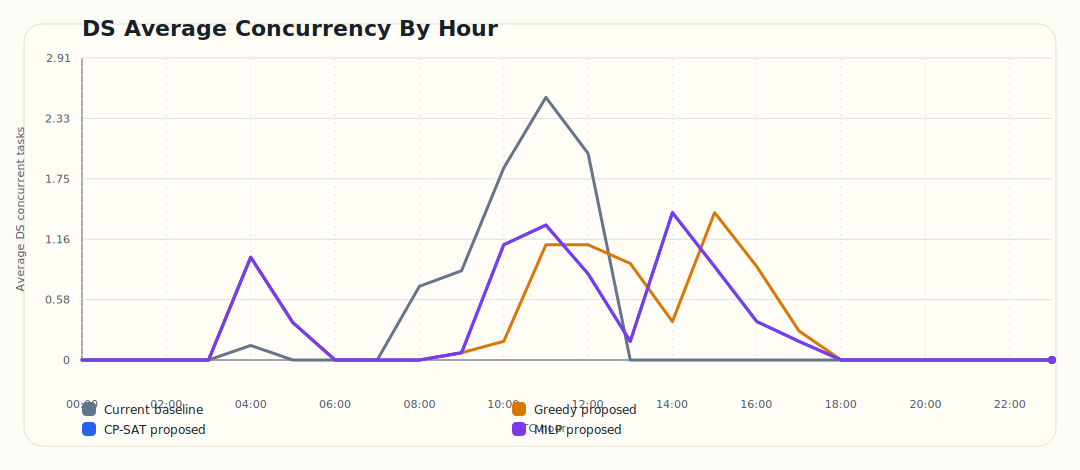

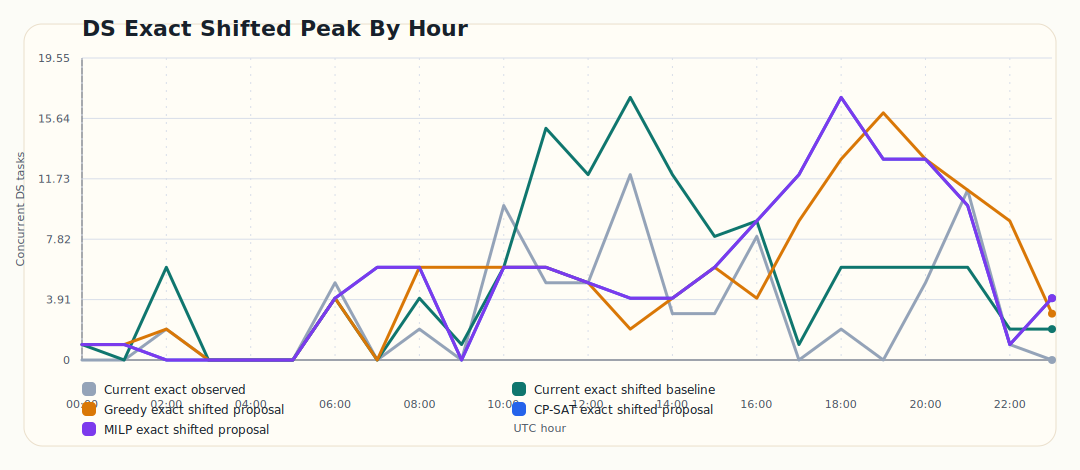

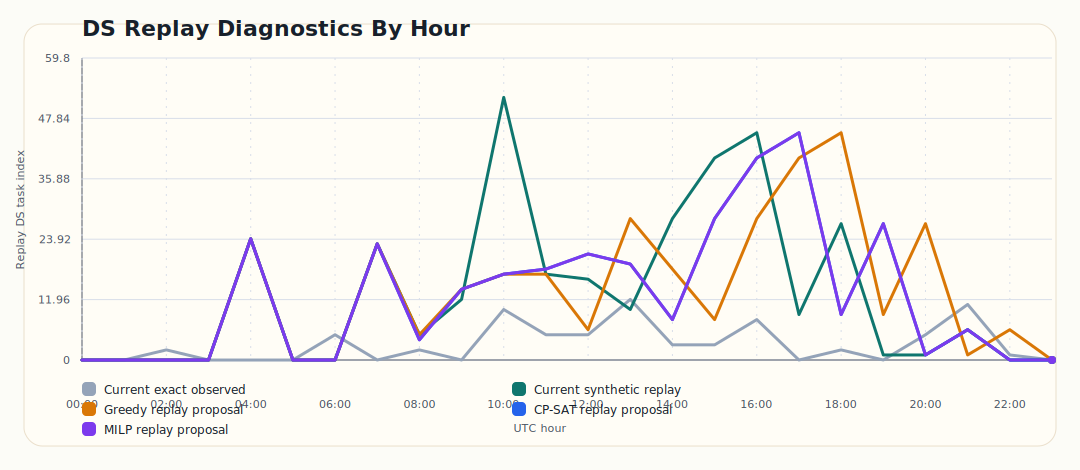

In [115]:
show_svg(
    build_svg_line_chart(
        comparison,
        title='DS Average Concurrency By Hour',
        y_label='Average DS concurrent tasks',
        series=[
            ('Current baseline', 'ds_avg_concurrency_current', '#64748b'),
            ('Greedy proposed', 'ds_avg_concurrency_greedy', solver_colors['greedy']),
            ('CP-SAT proposed', 'ds_avg_concurrency_cp_sat', solver_colors['cp_sat']),
            ('MILP proposed', 'ds_avg_concurrency_milp', solver_colors['milp']),
        ],
    )
)

show_svg(
    build_svg_line_chart(
        comparison,
        title='DS Exact Shifted Peak By Hour',
        y_label='Concurrent DS tasks',
        series=[
            ('Current exact observed', 'ds_peak_parallel_tasks_current', '#94a3b8'),
            ('Current exact shifted baseline', 'ds_peak_parallel_tasks_current_shifted_exact', '#0f766e'),
            ('Greedy exact shifted proposal', 'ds_peak_parallel_tasks_shifted_exact_greedy', solver_colors['greedy']),
            ('CP-SAT exact shifted proposal', 'ds_peak_parallel_tasks_shifted_exact_cp_sat', solver_colors['cp_sat']),
            ('MILP exact shifted proposal', 'ds_peak_parallel_tasks_shifted_exact_milp', solver_colors['milp']),
        ],
    )
)

show_svg(
    build_svg_line_chart(
        comparison,
        title='DS Replay Diagnostics By Hour',
        y_label='Replay DS task index',
        series=[
            ('Current exact observed', 'ds_peak_parallel_tasks_current', '#94a3b8'),
            ('Current synthetic replay', 'ds_peak_parallel_tasks_current_estimated', '#0f766e'),
            ('Greedy replay proposal', 'ds_peak_parallel_tasks_greedy', solver_colors['greedy']),
            ('CP-SAT replay proposal', 'ds_peak_parallel_tasks_cp_sat', solver_colors['cp_sat']),
            ('MILP replay proposal', 'ds_peak_parallel_tasks_milp', solver_colors['milp']),
        ],
    )
)

In [116]:
schedule_comparison = None
for solver in solvers:
    frame = proposal_frames[solver][['dag_id', 'proposed_schedule', 'strategy', 'wait_saved_minutes', 'shift_minutes']].copy()
    frame = frame.rename(columns={
        'proposed_schedule': f'proposed_schedule_{solver}',
        'strategy': f'strategy_{solver}',
        'wait_saved_minutes': f'wait_saved_minutes_{solver}',
        'shift_minutes': f'shift_minutes_{solver}',
    })
    if schedule_comparison is None:
        schedule_comparison = frame
    else:
        schedule_comparison = schedule_comparison.merge(frame, on='dag_id', how='outer')

delta_summary = pd.DataFrame(
    [
        {
            'solver': solver_labels[solver],
            'largest_global_avg_decrease_hour': comparison.loc[(comparison[f'global_avg_concurrency_{solver}'] - comparison['global_avg_concurrency_current']).idxmin(), 'hour'],
            'largest_global_avg_decrease': round(float((comparison[f'global_avg_concurrency_{solver}'] - comparison['global_avg_concurrency_current']).min()), 2),
            'largest_global_shifted_exact_peak_change_hour': comparison.loc[(comparison[f'global_peak_parallel_tasks_shifted_exact_{solver}'] - comparison['global_peak_parallel_tasks_current']).abs().idxmax(), 'hour'],
            'largest_global_shifted_exact_peak_change_vs_current_observed': round(float((comparison[f'global_peak_parallel_tasks_shifted_exact_{solver}'] - comparison['global_peak_parallel_tasks_current']).iloc[(comparison[f'global_peak_parallel_tasks_shifted_exact_{solver}'] - comparison['global_peak_parallel_tasks_current']).abs().idxmax()]), 2),
            'largest_global_replay_peak_increase_hour': comparison.loc[(comparison[f'global_peak_parallel_tasks_{solver}'] - comparison['global_peak_parallel_tasks_current_estimated']).idxmax(), 'hour'],
            'largest_global_replay_peak_increase_vs_replay_current': round(float((comparison[f'global_peak_parallel_tasks_{solver}'] - comparison['global_peak_parallel_tasks_current_estimated']).max()), 2),
        }
        for solver in solvers
    ]
)

if display is not None and Markdown is not None:
    display(Markdown('### Backend Schedule Comparison'))
    display(schedule_comparison.sort_values('dag_id'))
    display(Markdown('### Largest Hourly Moves By Backend'))
    display(delta_summary)
else:
    print('Backend Schedule Comparison')
    print(schedule_comparison.sort_values('dag_id').to_string(index=False))
    print('\nLargest Hourly Moves By Backend')
    print(delta_summary.to_string(index=False))

### Backend Schedule Comparison

,dag_id,proposed_schedule_greedy,strategy_greedy,wait_saved_minutes_greedy,shift_minutes_greedy,proposed_schedule_cp_sat,strategy_cp_sat,wait_saved_minutes_cp_sat,shift_minutes_cp_sat,proposed_schedule_milp,strategy_milp,wait_saved_minutes_milp,shift_minutes_milp
0,clv_model,45 9 * * *,upstream_ready_slot_search,150,160,45 9 * * *,upstream_ready_cp_sat,150,160,45 9 * * *,upstream_ready_milp,150,160
1,fork,45 13 * * *,upstream_ready_slot_search,90,400,45 12 * * *,upstream_ready_cp_sat,80,340,45 12 * * *,upstream_ready_milp,80,340
2,menu_generation,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0
3,menu_ranker,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0,"30 4,18 * * *",kept_existing_multi_slot_schedule,0,0
4,plum,0 15 * * 1,upstream_ready_slot_search,236,355,0 14 * * 1,upstream_ready_cp_sat,236,295,0 14 * * 1,upstream_ready_milp,236,295
5,relevance_scoring,15 10 * * *,upstream_ready_slot_search,183,190,0 11 * * *,upstream_ready_cp_sat,183,235,0 11 * * *,upstream_ready_milp,183,235
6,sales_forecast_v2,0 11 * * *,upstream_ready_slot_search,183,235,0 8 * * *,upstream_ready_cp_sat,55,55,0 8 * * *,upstream_ready_milp,55,55


### Largest Hourly Moves By Backend

,solver,largest_global_avg_decrease_hour,largest_global_avg_decrease,largest_global_shifted_exact_peak_change_hour,largest_global_shifted_exact_peak_change_vs_current_observed,largest_global_replay_peak_increase_hour,largest_global_replay_peak_increase_vs_replay_current
0,Greedy,10:00,-1.55,18:00,14.0,17:00,40.0
1,CP-SAT,11:00,-1.24,08:00,12.0,17:00,34.0
2,MILP,11:00,-1.24,08:00,12.0,17:00,34.0


## Reading The Results

On the current monday_ds data snapshot:

1. `monday_ds` now defaults to `concurrency_first`, so the optimizer is allowed to reject every candidate reschedule instead of returning a harmful one.
2. `greedy`, `cp_sat`, and `milp` currently all return the same practical outcome: no accepted schedule change. Their proposal curves therefore overlap exactly, which is why only the last rendered line may be visible in the chart.
3. The new shifted-exact peak metric remains the closest counterfactual to the scheduling question: it rigidly shifts the exact historical scoped task traces by the proposed schedule delta and recomputes hourly exact overlap.
4. The average-concurrency charts are still useful for estimated workload shape, but they should not be read as proof that the optimizer improved the exact concurrency objective. They are proxy estimates, not the hard acceptance rule.
5. For monday_ds, the correct reading is now simple: no backend found an acceptable reschedule under the strict global concurrency rule, so the system kept the current schedules unchanged.

If you change solver weights or add new scheduling constraints, rerun the three backend proposal builds and refresh the suffixed artifact copies before reopening this notebook.



## Effective-Start AuditThese tables expose the new audit input used by the optimizer:- `recent_observed_effective_start_utc`: recent empirical effective starts from recent runs of the same DAG.- `estimated_upstream_ready_utc`: dependency-based ready estimate after capping it with recent observed effective starts.If these two columns disagree materially, that DAG is a good candidate for manual review.

In [ ]:
effective_start_audits = {}
audit_columns = [
    'dag_id',
    'current_schedule',
    'proposed_schedule',
    'recent_observed_effective_start_utc',
    'estimated_upstream_ready_utc',
    'current_effective_start_utc',
    'proposed_effective_start_utc',
    'shift_minutes',
    'strategy',
]
for solver in solvers:
    frame = proposal_frames[solver].copy()
    if 'recent_observed_effective_start_utc' not in frame.columns:
        frame['recent_observed_effective_start_utc'] = ''
    effective_start_audits[solver] = frame[audit_columns].sort_values(['dag_id']).reset_index(drop=True)

if display is not None and Markdown is not None:
    for solver in solvers:
        display(Markdown(f"### {solver_labels[solver]} recent observed vs estimated ready"))
        display(effective_start_audits[solver])
else:
    for solver in solvers:
        print(f'--- {solver_labels[solver]} ---')
        print(effective_start_audits[solver].to_string(index=False))
